# Diffusion-Only vs Jump-Diffusion: Simple Comparison

**Black-Scholes style (diffusion only) vs our jump-diffusion model**

In prediction markets, a pure diffusion model assumes all price moves are continuous noise.
Our jump-diffusion model separates **jumps** (information-driven) from **diffusion** (noise).

This notebook compares the two approaches on real Kalshi data.

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.as_detector import run_as_detection
from src.mm_backtest import analyse_fill_toxicity

CACHE = os.path.join('..', 'cache', 'kalshi_hf')
files = sorted(glob.glob(os.path.join(CACHE, '*_trades.parquet')))
df = pd.read_parquet(files[0]).sort_values('timestamp').reset_index(drop=True)
ticker = os.path.basename(files[0]).replace('_trades.parquet', '')
print(f"Loaded {ticker}: {len(df)} trades")

Loaded KXTOPMONTHLY-25AUG-BAD: 2 trades


## 1. Run Both Models

- **Diffusion-only**: Pure Black-Scholes style — all moves attributed to diffusion. Gamma=0 everywhere.
- **Jump-diffusion**: Separates jumps from diffusion. Gamma>0.5 indicates jump.

In [2]:
# Diffusion-only (Black-Scholes style)
res_diff = run_as_detection(df, ticker=ticker, diffusion_only=True)

# Jump-diffusion (our full model)
res_jump = run_as_detection(df, ticker=ticker, diffusion_only=False)

print(f"Diffusion-only: gamma always 0, sigma_b ≈ {np.sqrt(np.nanmean(res_diff.sigma_b_sq)):.4f}")
print(f"Jump-diffusion: {int((res_jump.gamma > 0.5).sum())} jumps detected, sigma_b ≈ {np.sqrt(np.nanmean(res_jump.sigma_b_sq)):.4f}")

[2026-03-09 07:00:40 UTC] [INFO] tauroi.as_detector — AS detection KXTOPMONTHLY-25AUG-BAD: 2 trades, 0 jumps (γ>0.5), 0 bursts, 0 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.00000
[2026-03-09 07:00:40 UTC] [INFO] tauroi.as_detector — AS detection KXTOPMONTHLY-25AUG-BAD: 2 trades, 0 jumps (γ>0.5), 0 bursts, 0 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.01000
Diffusion-only: gamma always 0, sigma_b ≈ 0.0001
Jump-diffusion: 0 jumps detected, sigma_b ≈ 0.0001


## 2. Visual Comparison: Gamma (Jump Signal)

Diffusion-only: gamma=0 always — no jump detection.
Jump-diffusion: gamma spikes where the model attributes the move to a jump.

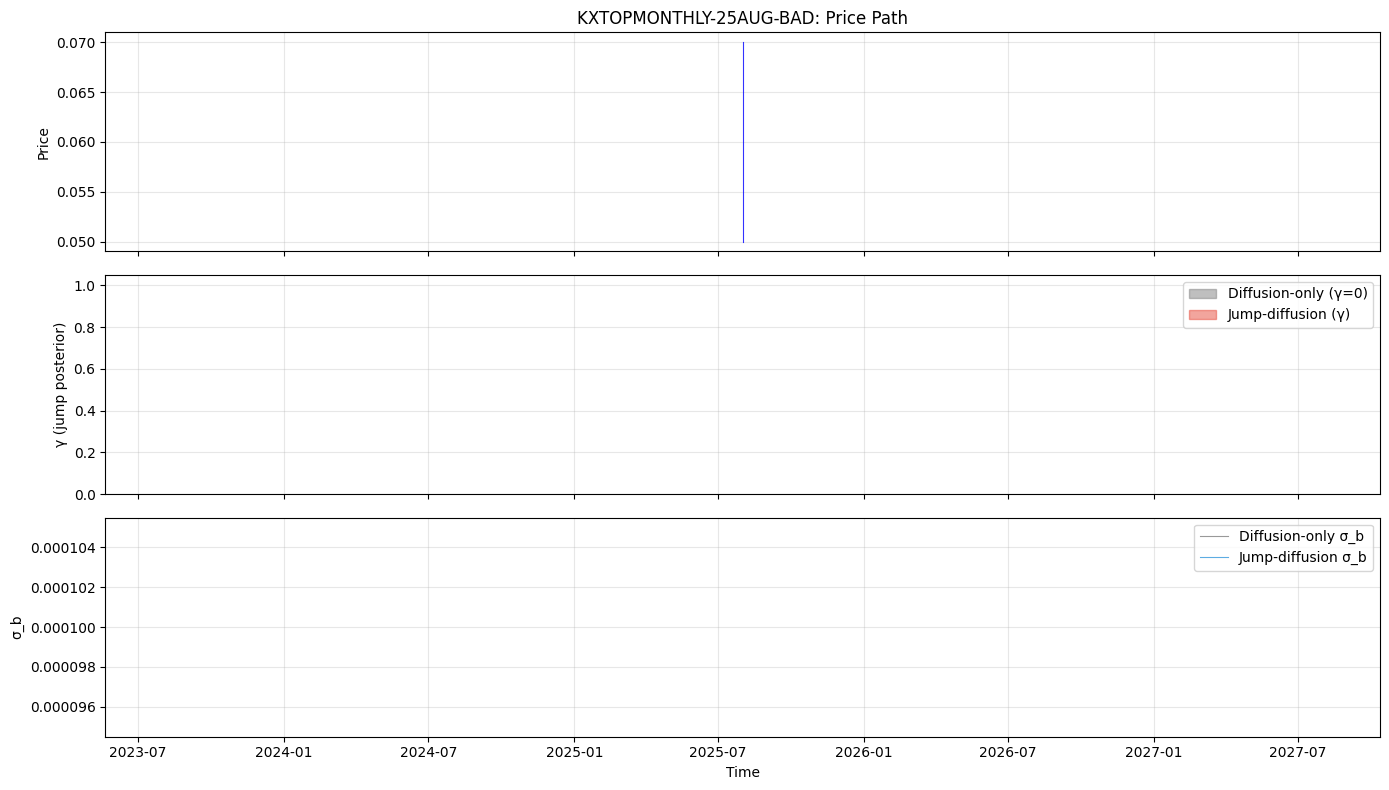

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
ts = pd.to_datetime(res_jump.timestamps)
axes[0].plot(ts, res_jump.prices, 'b-', lw=0.8, alpha=0.8)
axes[0].set_ylabel('Price'); axes[0].set_title(f'{ticker}: Price Path'); axes[0].grid(alpha=0.3)
# Gamma: diffusion=0, jump-diffusion shows spikes
axes[1].fill_between(ts, 0, res_diff.gamma, color='gray', alpha=0.5, label='Diffusion-only (γ=0)')
axes[1].fill_between(ts, 0, res_jump.gamma, color='#e74c3c', alpha=0.5, label='Jump-diffusion (γ)')
axes[1].set_ylabel('γ (jump posterior)'); axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)
# Sigma_b: diffusion-only inflates to absorb "jumps" as noise
axes[2].plot(ts, np.sqrt(res_diff.sigma_b_sq), 'gray', lw=0.8, alpha=0.8, label='Diffusion-only σ_b')
axes[2].plot(ts, np.sqrt(res_jump.sigma_b_sq), '#3498db', lw=0.8, alpha=0.8, label='Jump-diffusion σ_b')
axes[2].set_ylabel('σ_b'); axes[2].set_xlabel('Time'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Fill Toxicity: Which Model Better Identifies Toxic Flow?

We validate by checking: after flagged trades, do prices move more adversely?
- **Jump-diffusion**: Uses gamma (jump posterior) + burst → AS score. Threshold 0.5.
- **Diffusion-only**: Gamma=0, so AS score = 0.3×burst only (max ~0.3). We use threshold 0.2 to capture burst-only flags for a fair comparison.

In [4]:
# Diffusion-only: AS score maxes at ~0.3 (bursts only), so use lower threshold
tox_diff = analyse_fill_toxicity(res_diff, mtm_horizons=[30, 60], as_threshold=0.2)
tox_jump = analyse_fill_toxicity(res_jump, mtm_horizons=[30, 60], as_threshold=0.5)

print("Fill toxicity: Flagged vs Unflagged — mean adverse move (¢)")
print("-" * 70)
print("Diffusion-only (AS score from bursts only):")
print(tox_diff[['horizon_trades', 'mean_move_flagged', 'mean_move_unflagged', 'ratio', 'p_value']].to_string(index=False))
print("\nJump-diffusion (AS score from gamma + bursts):")
print(tox_jump[['horizon_trades', 'mean_move_flagged', 'mean_move_unflagged', 'ratio', 'p_value']].to_string(index=False))

Fill toxicity: Flagged vs Unflagged — mean adverse move (¢)
----------------------------------------------------------------------
Diffusion-only (AS score from bursts only):


KeyError: "None of [Index(['horizon_trades', 'mean_move_flagged', 'mean_move_unflagged', 'ratio',\n       'p_value'],\n      dtype='object')] are in the [columns]"

## 4. Summary

| Model | Gamma | Sigma_b | AS Score Source | Use Case |
|-------|-------|---------|-----------------|----------|
| **Diffusion-only** | 0 | Inflated (absorbs jumps) | Bursts only | Baseline; no jump detection |
| **Jump-diffusion** | >0 at jumps | Lower (jumps separated) | Gamma + Bursts | Adverse-selection detection |

The jump component lets us identify information-driven moves (jumps) vs noise (diffusion).
Without it, large moves get attributed to diffusion and we lose the ability to flag informed flow.